# 01 - Z-Score / Moving Average Anomaly Detection

**PolyWatch — Market Integrity Monitoring System**  
**Member C — Core Algorithm Module**

This notebook demonstrates the Z-Score based anomaly detection algorithm
for detecting sudden price manipulation in Polymarket prediction markets.

## Strategies
1. Multi-window rolling Z-Score (6h / 24h / 72h)
2. EWMA (Exponentially Weighted Moving Average) deviation
3. Price return rate spikes
4. Anomaly clustering

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from core_analysis.zscore_detector import ZScoreDetector, ZScoreConfig, run_zscore_analysis
from core_analysis.db_interface import get_price_series, get_active_slugs

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('Imports OK')

Imports OK


## 1. Load Price Data

/Users/qidahe/6290/notebooks/../core_analysis/db_interface.py:53: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=params,


Market: presidential-election-winner-2024
Data points: 7356
Time range: 2024-01-05 00:00:03+00:00 ~ 2024-11-06 15:00:02+00:00
Price range: 0.3950 ~ 0.9985


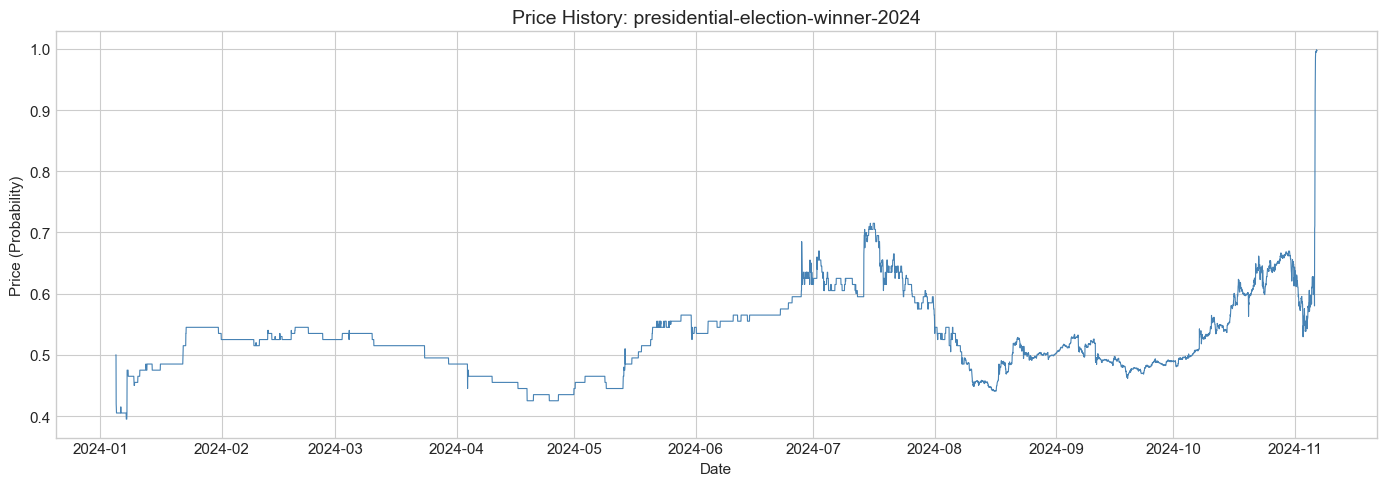

In [2]:
# Load 2024 US Presidential Election data for backtesting
slug = 'presidential-election-winner-2024'
price_df = get_price_series(slug)
price_series = price_df['price']

print(f'Market: {slug}')
print(f'Data points: {len(price_series)}')
print(f'Time range: {price_series.index[0]} ~ {price_series.index[-1]}')
print(f'Price range: {price_series.min():.4f} ~ {price_series.max():.4f}')

# Plot raw prices
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(price_series.index, price_series.values, linewidth=0.8, color='steelblue')
ax.set_title(f'Price History: {slug}', fontsize=14)
ax.set_ylabel('Price (Probability)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.show()

## 2. Run Z-Score Detection (Default Parameters)

In [3]:
# Run with default config
result = run_zscore_analysis(price_series)

print('=== Detection Summary ===')
summary = result['summary']
for k, v in summary.items():
    if k != 'config':
        print(f'  {k}: {v}')

print(f'\n=== Config ===')
for k, v in summary['config'].items():
    print(f'  {k}: {v}')

=== Detection Summary ===
  total_points: 7354
  anomaly_points: 317
  anomaly_rate: 4.31
  high_severity: 39
  medium_severity: 278
  clusters: 79

=== Config ===
  windows: [6, 24, 72]
  z_threshold: 2.5
  return_spike_threshold: 0.05


## 3. Visualize Anomalies on Price Chart

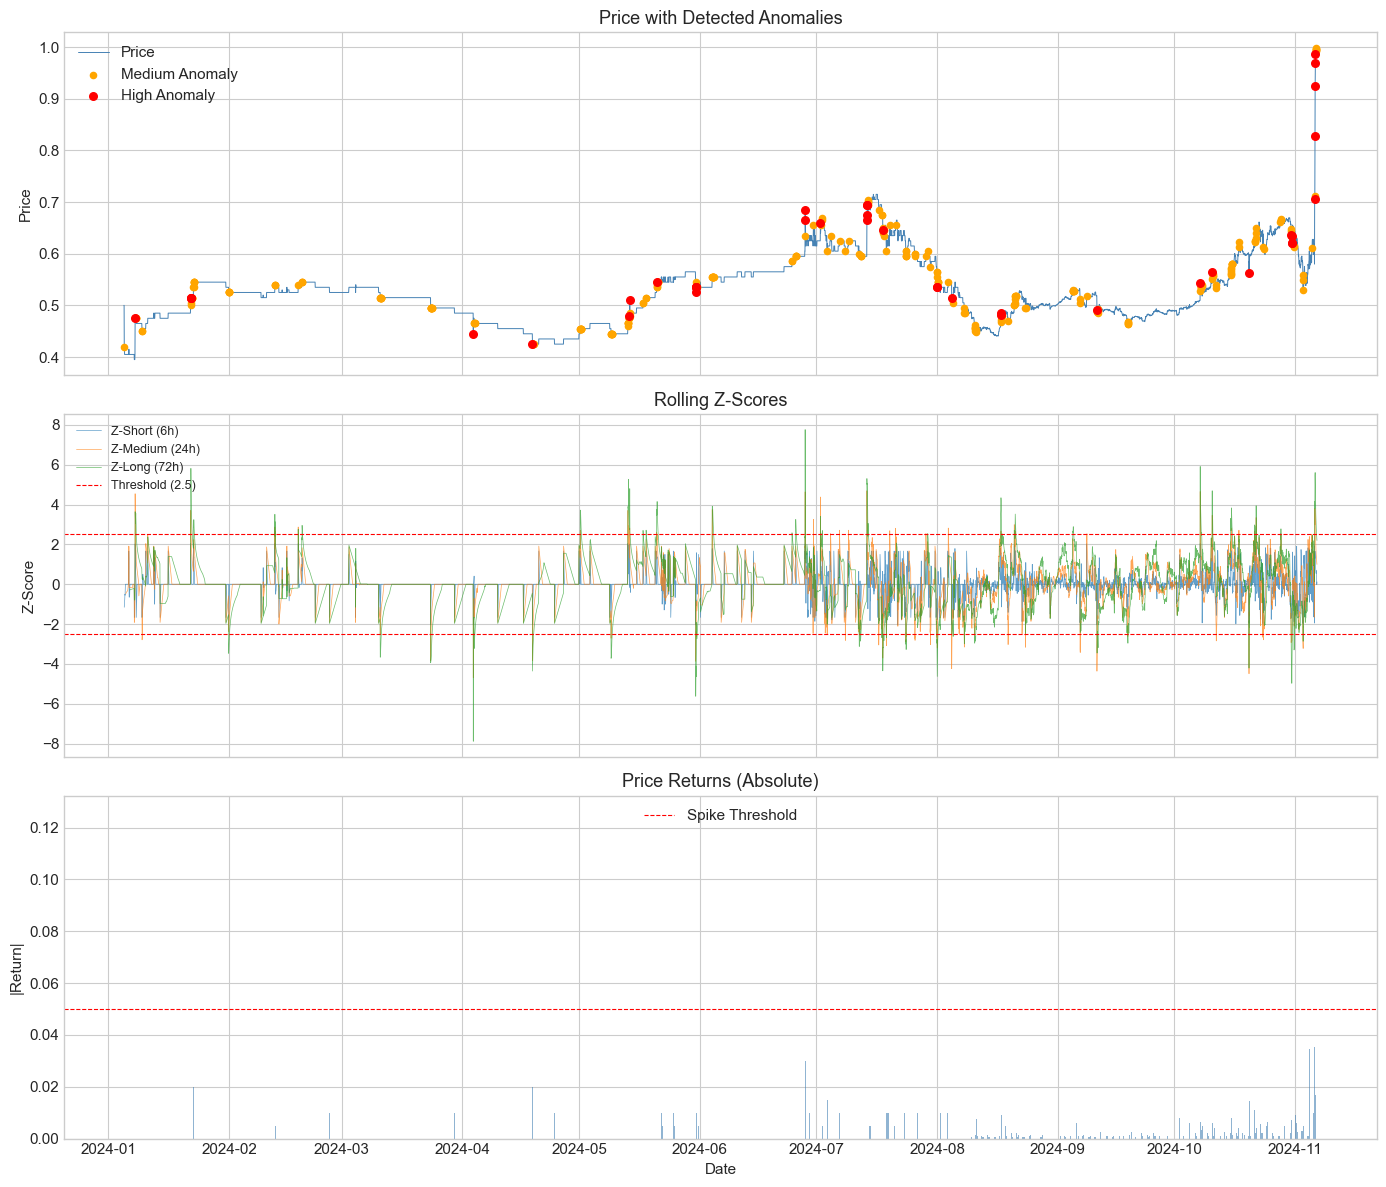

In [4]:
result_df = result['result_df']
anomalies_df = result['anomalies_df']

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Price with anomalies highlighted
ax = axes[0]
ax.plot(result_df.index, result_df['price'], linewidth=0.7, color='steelblue', label='Price')
medium_mask = anomalies_df['severity'] == 'medium'
high_mask = anomalies_df['severity'] == 'high'
if medium_mask.any():
    ax.scatter(anomalies_df.index[medium_mask], anomalies_df.loc[medium_mask, 'price'],
               color='orange', s=20, zorder=5, label='Medium Anomaly')
if high_mask.any():
    ax.scatter(anomalies_df.index[high_mask], anomalies_df.loc[high_mask, 'price'],
               color='red', s=30, zorder=5, label='High Anomaly')
ax.set_title('Price with Detected Anomalies', fontsize=13)
ax.set_ylabel('Price')
ax.legend(loc='upper left')

# Panel 2: Z-Scores
ax = axes[1]
ax.plot(result_df.index, result_df['z_short'], linewidth=0.5, alpha=0.7, label='Z-Short (6h)')
ax.plot(result_df.index, result_df['z_medium'], linewidth=0.5, alpha=0.7, label='Z-Medium (24h)')
ax.plot(result_df.index, result_df['z_long'], linewidth=0.5, alpha=0.7, label='Z-Long (72h)')
ax.axhline(y=2.5, color='red', linestyle='--', linewidth=0.8, label='Threshold (2.5)')
ax.axhline(y=-2.5, color='red', linestyle='--', linewidth=0.8)
ax.set_title('Rolling Z-Scores', fontsize=13)
ax.set_ylabel('Z-Score')
ax.legend(loc='upper left', fontsize=9)

# Panel 3: Price returns
ax = axes[2]
ax.bar(result_df.index, result_df['price_return'], width=0.02, color='steelblue', alpha=0.6)
ax.axhline(y=0.05, color='red', linestyle='--', linewidth=0.8, label='Spike Threshold')
ax.set_title('Price Returns (Absolute)', fontsize=13)
ax.set_ylabel('|Return|')
ax.set_xlabel('Date')
ax.legend()

plt.tight_layout()
plt.show()

## 4. Anomaly Clusters

In [5]:
clusters = result['clusters']
print(f'Total clusters: {len(clusters)}\n')

if clusters:
    cluster_df = pd.DataFrame(clusters)
    print(cluster_df[['start', 'end', 'duration_hours', 'peak_z', 'peak_price', 'count', 'severity']].to_string())
else:
    print('No anomaly clusters detected.')

Total clusters: 79

                       start                       end  duration_hours  peak_z  peak_price  count severity
0  2024-01-05 02:00:03+00:00 2024-01-05 02:00:03+00:00             0.0    1.15      0.4200      1   medium
1  2024-01-07 21:00:03+00:00 2024-01-08 03:00:03+00:00             6.0    4.55      0.4750      7     high
2  2024-01-09 16:00:02+00:00 2024-01-09 17:00:03+00:00             1.0    2.79      0.4500      2   medium
3  2024-01-22 03:00:03+00:00 2024-01-22 13:00:03+00:00            10.0    5.82      0.5150     11     high
4  2024-01-22 21:00:03+00:00 2024-01-23 02:00:02+00:00             5.0    3.24      0.5450      6   medium
5  2024-01-31 22:00:02+00:00 2024-02-01 02:00:03+00:00             4.0    3.47      0.5250      5   medium
6  2024-02-12 19:00:02+00:00 2024-02-12 22:00:03+00:00             3.0    3.51      0.5400      3   medium
7  2024-02-18 19:00:02+00:00 2024-02-18 19:00:02+00:00             0.0    2.88      0.5400      1   medium
8  2024-02-19 19:

## 5. Parameter Sensitivity Analysis

 threshold  anomalies  rate_pct  high  clusters
       1.5       1856     25.24    39       192
       2.0        688      9.36    39       110
       2.5        317      4.31    39        79
       3.0        159      2.16    39        47
       3.5         89      1.21    39        32
       4.0         40      0.54    39        22
       5.0         16      0.22    14        10


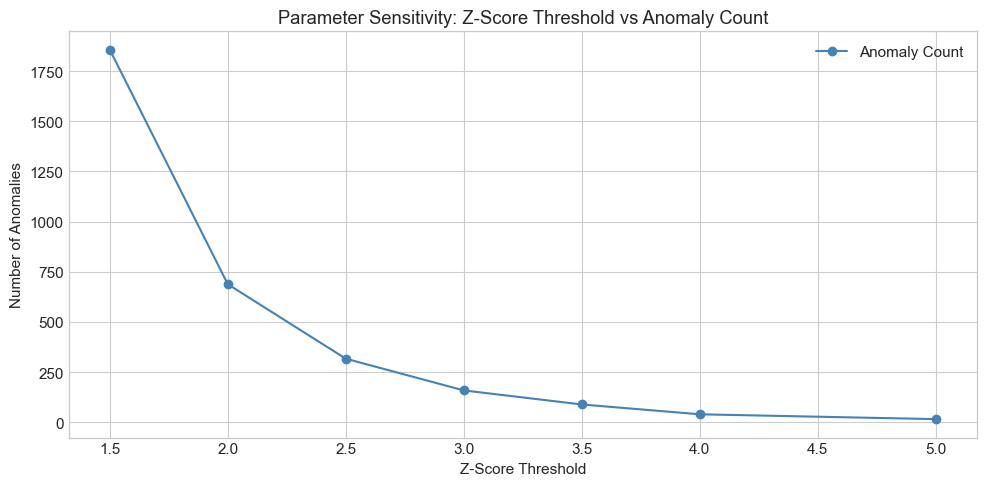

In [6]:
# Test different thresholds
thresholds = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
sensitivity = []

for t in thresholds:
    cfg = ZScoreConfig(z_threshold=t)
    r = run_zscore_analysis(price_series, cfg)
    s = r['summary']
    sensitivity.append({
        'threshold': t,
        'anomalies': s['anomaly_points'],
        'rate_pct': s['anomaly_rate'],
        'high': s['high_severity'],
        'clusters': s['clusters'],
    })

sens_df = pd.DataFrame(sensitivity)
print(sens_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sens_df['threshold'], sens_df['anomalies'], 'o-', color='steelblue', label='Anomaly Count')
ax.set_xlabel('Z-Score Threshold')
ax.set_ylabel('Number of Anomalies')
ax.set_title('Parameter Sensitivity: Z-Score Threshold vs Anomaly Count')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Anomaly Events for Database

In [7]:
events = result['events']
print(f'Total anomaly events ready for write_anomaly(): {len(events)}')

if events:
    print('\nSample event:')
    import json
    print(json.dumps(events[0], indent=2, default=str))

Total anomaly events ready for write_anomaly(): 317

Sample event:
{
  "detected_at": "2024-01-05 02:00:03+00:00",
  "event_type": "zscore_spike",
  "severity": "medium",
  "detail": {
    "z_short": -1.1547,
    "z_medium": null,
    "z_long": null,
    "z_ewma": -1.0839,
    "z_max": 1.1547,
    "price": 0.42,
    "price_return": 0.08,
    "strategy": "return_spike",
    "market_slug": ""
  }
}


---

## Summary

The Z-Score detector successfully identifies price anomalies using:
- Multi-window rolling Z-Scores for different time horizons
- EWMA for more responsive detection
- Price return spikes for instantaneous changes

Key findings are exported as anomaly events compatible with the shared `anomaly_events` database table.